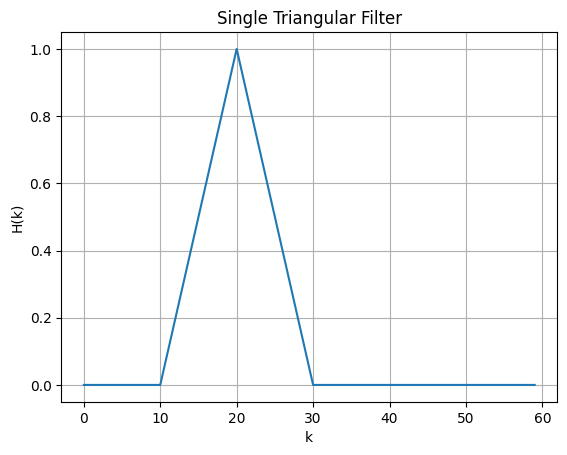

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def triangular_filter(k, a, b, c):
    H = np.zeros_like(k, dtype=float)
    
    for i in range(len(k)):
        if k[i] < a:
            H[i] = 0
        elif a <= k[i] <= b:
            H[i] = (k[i] - a) / (b - a)
        elif b <= k[i] <= c:
            H[i] = (c - k[i]) / (c - b)
        else:
            H[i] = 0
    return H

# Parameters
k = np.arange(0, 60)
a, b, c = 10, 20, 30

H = triangular_filter(k, a, b, c)

plt.plot(k, H)
plt.title("Single Triangular Filter")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.grid()
plt.show()

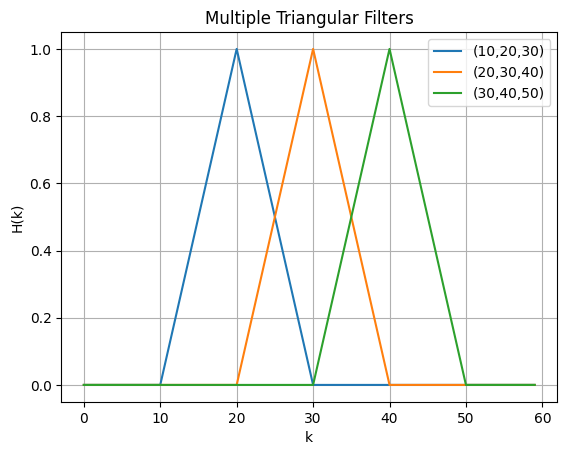

In [2]:
triangles = [(10, 20, 30), (20, 30, 40), (30, 40, 50)]

k = np.arange(0, 60)

plt.figure()

for (a, b, c) in triangles:
    H = triangular_filter(k, a, b, c)
    plt.plot(k, H, label=f"({a},{b},{c})")

plt.title("Multiple Triangular Filters")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.legend()
plt.grid()
plt.show()

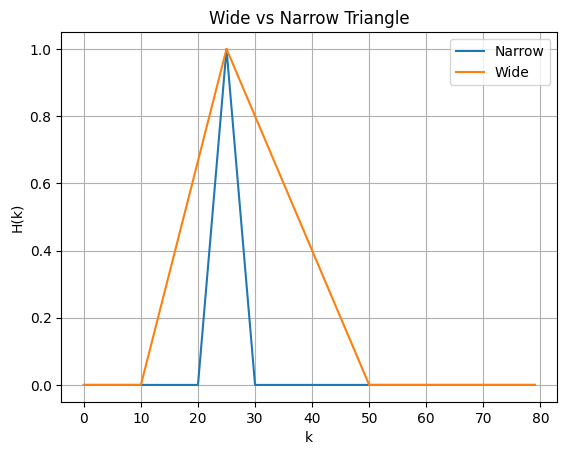

In [3]:
k = np.arange(0, 80)

# Narrow triangle
H1 = triangular_filter(k, 20, 25, 30)

# Wide triangle
H2 = triangular_filter(k, 10, 25, 50)

plt.plot(k, H1, label="Narrow")
plt.plot(k, H2, label="Wide")

plt.title("Wide vs Narrow Triangle")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.legend()
plt.grid()
plt.show()


FFT Bin Indices:
 [  0   2   6   9  13  18  23  29  36  43  52  61  72  84  97 113 130 150
 172 196 224 256]


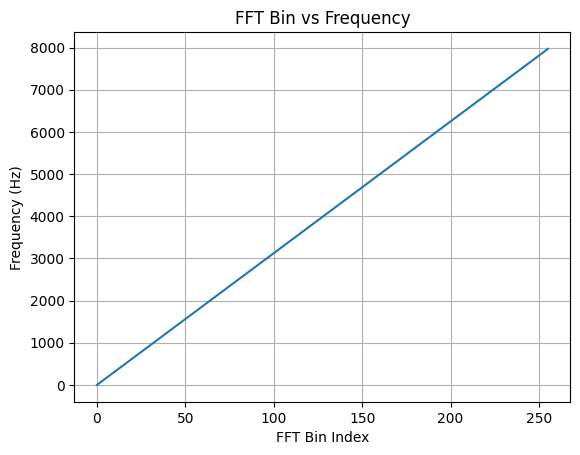

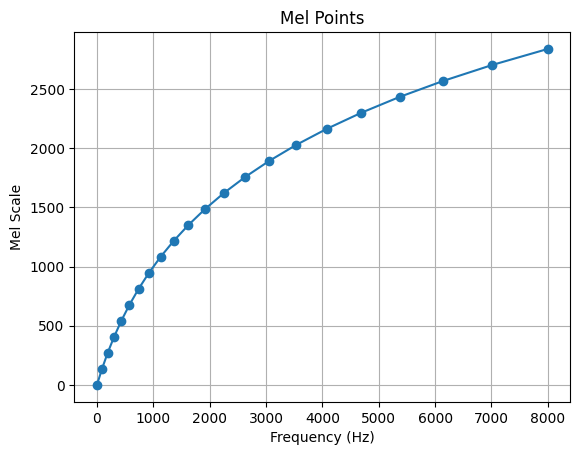


Triangular Filter Points (a, b, c):
Filter 1: (0, 2, 6)
Filter 2: (2, 6, 9)
Filter 3: (6, 9, 13)
Filter 4: (9, 13, 18)
Filter 5: (13, 18, 23)
Filter 6: (18, 23, 29)
Filter 7: (23, 29, 36)
Filter 8: (29, 36, 43)
Filter 9: (36, 43, 52)
Filter 10: (43, 52, 61)
Filter 11: (52, 61, 72)
Filter 12: (61, 72, 84)
Filter 13: (72, 84, 97)
Filter 14: (84, 97, 113)
Filter 15: (97, 113, 130)
Filter 16: (113, 130, 150)
Filter 17: (130, 150, 172)
Filter 18: (150, 172, 196)
Filter 19: (172, 196, 224)
Filter 20: (196, 224, 256)


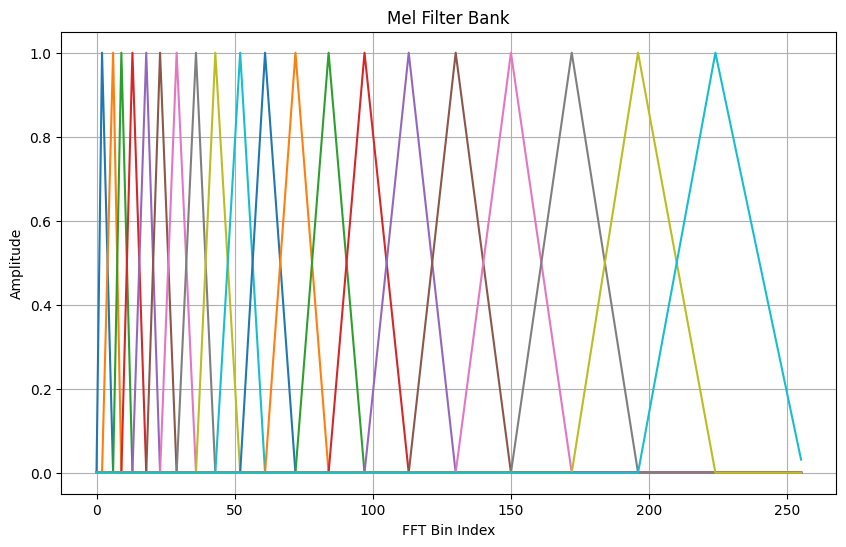


Try modifying these values to observe changes:
fs = 8000 or 22050
N = 1024
M = 10 or 40


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Define Parameters
# -----------------------------
fs = 16000        # Sampling frequency
N = 512           # FFT size
M = 20            # Number of filters

fmin = 0
fmax = fs / 2

# -----------------------------
# Step 2: Hz ↔ Mel Conversion
# -----------------------------
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)

# Convert limits
mel_min = hz_to_mel(fmin)
mel_max = hz_to_mel(fmax)

# -----------------------------
# Step 3: Equally spaced Mel points
# -----------------------------
mel_points = np.linspace(mel_min, mel_max, M + 2)

# -----------------------------
# Step 4: Convert Mel → Hz
# -----------------------------
freq_points = mel_to_hz(mel_points)

# -----------------------------
# Step 5: Convert Hz → FFT bins
# -----------------------------
bins = np.floor((N + 1) * freq_points / fs).astype(int)

print("\nFFT Bin Indices:\n", bins)

# -----------------------------
# (i) FFT Bin vs Frequency Plot
# -----------------------------
k = np.arange(0, N//2)
freqs = (k * fs) / N

plt.figure()
plt.plot(k, freqs)
plt.title("FFT Bin vs Frequency")
plt.xlabel("FFT Bin Index")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()

# -----------------------------
# (ii) Plot Mel Points
# -----------------------------
plt.figure()
plt.plot(freq_points, mel_points, 'o-')
plt.title("Mel Points")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mel Scale")
plt.grid()
plt.show()

# -----------------------------
# (iii) Print triangular points
# -----------------------------
print("\nTriangular Filter Points (a, b, c):")

for i in range(1, M+1):
    a = bins[i-1]
    b = bins[i]
    c = bins[i+1]
    print(f"Filter {i}: ({a}, {b}, {c})")

# -----------------------------
# Step 6: Construct Filter Bank
# -----------------------------
filter_bank = np.zeros((M, N//2))

for m in range(1, M+1):
    a = bins[m-1]
    b = bins[m]
    c = bins[m+1]
    
    # Rising edge
    for k in range(a, b):
        filter_bank[m-1, k] = (k - a) / (b - a)
    
    # Falling edge
    for k in range(b, c):
        filter_bank[m-1, k] = (c - k) / (c - b)

# -----------------------------
# (iv) Plot Mel Filter Bank
# -----------------------------
plt.figure(figsize=(10, 6))

for i in range(M):
    plt.plot(filter_bank[i])

plt.title("Mel Filter Bank")
plt.xlabel("FFT Bin Index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# -----------------------------
# (v) Experiment Section
# -----------------------------
print("\nTry modifying these values to observe changes:")
print("fs = 8000 or 22050")
print("N = 1024")
print("M = 10 or 40")